In [1]:
import torch
import numpy as np
from PIL import Image
import shutil
import os
os.chdir('../')
from cxas.segmentor import CXAS
import pandas as pd


In [2]:
import cxas

In [3]:
model = CXAS(
    model_name = 'UNet_ResNet50_default',
    gpus       = 'cpu'
)

In [5]:
# path = '/Users/constantinseibold/Downloads/CXAS_CX_DATA_CURATED_2025-04-12/cxas_pe_1/Cbs2685/Thorax - 3KLEFEI2OQHZ/Thorax_pa_1/IM-0003-0001.dcm'

path = '/Users/constantinseibold/Downloads/CXAS_CX_DATA_CURATED_2025-04-12/cxas_pe_1/Cbs2685/Thorax - 3KLEFEI2OQHZ/Thorax_pa_1/'

# model.extract_features_for_file(path, 'radiomics', do_store=True)
model.extract_features_for_folder(path, './here','radiomics', do_store=True, create=True)

???
 ---  (159, 512, 512) torch.Size([1, 512, 512])


  0%|          | 0/159 [00:00<?, ?it/s]/opt/anaconda3/envs/cxas/lib/python3.9/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 159/159 [03:02<00:00,  1.15s/it]


{'spine_diagnostics_Versions_PyRadiomics': 'v3.0.1',
 'spine_diagnostics_Versions_Numpy': '1.26.4',
 'spine_diagnostics_Versions_SimpleITK': '2.4.1',
 'spine_diagnostics_Versions_PyWavelet': '1.6.0',
 'spine_diagnostics_Versions_Python': '3.9.22',
 'spine_diagnostics_Configuration_Settings': {'minimumROIDimensions': 2,
  'minimumROISize': None,
  'normalize': False,
  'normalizeScale': 1,
  'removeOutliers': None,
  'resampledPixelSpacing': None,
  'interpolator': 'sitkBSpline',
  'preCrop': False,
  'padDistance': 5,
  'distances': [1],
  'force2D': False,
  'force2Ddimension': 0,
  'resegmentRange': None,
  'label': 1,
  'additionalInfo': True},
 'spine_diagnostics_Configuration_EnabledImageTypes': {'Original': {},
  'Exponential': {},
  'Gradient': {},
  'LBP2D': {},
  'LBP3D': {},
  'LoG': {},
  'Logarithm': {},
  'Square': {},
  'SquareRoot': {},
  'Wavelet': {}},
 'spine_diagnostics_Image-original_Hash': '5438b8257eb8649757a771080e819fc5e7aa1d80',
 'spine_diagnostics_Image-origin

In [4]:

sample_output = model.process_file(
        filename = path
        )
mask = sample_output['segmentation_preds']


???


In [5]:
import numpy as np
import SimpleITK as sitk
import pandas as pd
from radiomics import featureextractor
import os
import torch.nn.functional as F
from tqdm import tqdm

image_sitk = sitk.ReadImage(path)
image_array = sitk.GetArrayFromImage(image_sitk)
image_array = F.interpolate(torch.tensor(image_array).unsqueeze(0).float(), (512,512)).numpy()[0]


image_sitk = sitk.GetImageFromArray(image_array)

mask_np = F.interpolate(mask.float(), image_array.shape[1:], mode='nearest').numpy()[0]

# Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.enableAllFeatures()
extractor.enableAllImageTypes()


# Store all features
all_features = []

for class_idx in tqdm(range(mask_np.shape[0])):
    mask_channel = mask_np[class_idx:class_idx+1]

    # Skip empty masks
    if not mask_channel.sum():
        continue

    mask_sitk = sitk.GetImageFromArray(mask_channel.astype(np.uint8))

    # You can pass a label, but since it's binary, label=1 works
    result = extractor.execute(image_sitk, mask_sitk, label=1)

    # Add class info and flatten dict
    result_flat = {'class': class_idx}
    result_flat.update(result)

    all_features.append(result_flat)

# Convert to DataFrame
df = pd.DataFrame(all_features)

df

  0%|          | 0/159 [00:00<?, ?it/s]parameter force2D must be set to True to enable shape2D extraction
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Calculating Local Binary Pattern in 2D, but extracting features in 3D. Use with caution!
/opt/anaconda3/envs/cxas/lib/python3.9/site-packages/skimage/feature/texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Could not load required package "scipy" or "trimesh", cannot implement filter LBP 3D
Image

,class,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,...,wavelet-LLL_glszm_SmallAreaHighGrayLevelEmphasis,wavelet-LLL_glszm_SmallAreaLowGrayLevelEmphasis,wavelet-LLL_glszm_ZoneEntropy,wavelet-LLL_glszm_ZonePercentage,wavelet-LLL_glszm_ZoneVariance,wavelet-LLL_ngtdm_Busyness,wavelet-LLL_ngtdm_Coarseness,wavelet-LLL_ngtdm_Complexity,wavelet-LLL_ngtdm_Contrast,wavelet-LLL_ngtdm_Strength
0,0,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,34916.20815646615,5.484886659126053e-05,7.740839655836239,0.7709007896759766,0.4787030134844037,0.019825261147831487,0.0006752233541282724,107099.26301677819,0.10443511328941098,33.08431868659056
1,1,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,12585.541010586072,0.0007728282660117753,7.7344089797983475,0.8189821182943604,0.31930253768422084,0.004927416178257812,0.00788972175142025,88611.62323586017,0.31482632215317696,99.06368707194112
2,2,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,35582.65524429718,6.18879319391424e-05,7.642771326694603,0.7584418577849488,0.521568066690863,0.017399190211348677,0.0008037277688707246,88413.38491701178,0.09643559608228995,48.79900073585974
3,3,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,6843.550387871494,0.00043064085022204965,7.188904443683657,0.8109112531589119,0.3441602781192004,0.026601801487987655,0.00254312318709767,40393.11355906108,0.2616472346956633,19.16066736232006
4,8,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,18786.934488932293,0.005669097230613101,6.960580201160264,0.8797250859106529,0.1727142333984375,0.004017993643954096,0.019178351529517468,217039.76849550422,6.9659959604334665,302.201170335062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,153,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,28523.11182679633,0.00022368390398773205,8.990584500444168,0.8190333458224054,0.3356726536413624,0.009525316541348236,0.002533671737550069,140222.3439377552,0.4955833389551519,97.9948347074554
135,154,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,23220.589711271412,0.00019516915375731558,7.716683927271419,0.7706691392365941,0.48935244468986117,0.004077938558996359,0.005044787814696314,67644.525330578,0.15635024434731867,187.19923560141163
136,155,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,...,23391.253826145636,0.0003987173313649331,7.528357501798181,0.7418032786885246,0.60444837866162,0.0019318141035311344,0.009753030917574344,59670.51839064843,0.18605982196381934,519.728607532407
137,156,v3.0.1,1.26.4,2.4.1,1.6.0,3.9.22,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'Exponential': {}, 'Gradient'...",f39547066f557b8e1ff5fe892d35154cd226949d,3D,..

In [7]:
list(df.keys())

['class',
 'diagnostics_Versions_PyRadiomics',
 'diagnostics_Versions_Numpy',
 'diagnostics_Versions_SimpleITK',
 'diagnostics_Versions_PyWavelet',
 'diagnostics_Versions_Python',
 'diagnostics_Configuration_Settings',
 'diagnostics_Configuration_EnabledImageTypes',
 'diagnostics_Image-original_Hash',
 'diagnostics_Image-original_Dimensionality',
 'diagnostics_Image-original_Spacing',
 'diagnostics_Image-original_Size',
 'diagnostics_Image-original_Mean',
 'diagnostics_Image-original_Minimum',
 'diagnostics_Image-original_Maximum',
 'diagnostics_Mask-original_Hash',
 'diagnostics_Mask-original_Spacing',
 'diagnostics_Mask-original_Size',
 'diagnostics_Mask-original_BoundingBox',
 'diagnostics_Mask-original_VoxelNum',
 'diagnostics_Mask-original_VolumeNum',
 'diagnostics_Mask-original_CenterOfMassIndex',
 'diagnostics_Mask-original_CenterOfMass',
 'original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_LeastAxisLength',
 'original_shape_MajorAxisLength',
 'original_sha

In [4]:
input_path = '/Users/constantinseibold/Downloads/CXAS_CX_DATA_CURATED_2025-04-12'
out_path = '/Users/constantinseibold/workspace/research/matthias_cxas/xray_results3'

model.extract_features_for_folder(
    input_directory_name = input_path,  
    output_directory = out_path,
    feat_to_extract = 'area',
    create = True, 
)

pd.read_csv('./out_feats/images.csv')

??


  0%|          | 0/192 [00:00<?, ?it/s]

???


  1%|          | 1/192 [00:00<01:10,  2.69it/s]

???


...

???


 99%|█████████▉| 191/192 [01:01<00:00,  2.99it/s]

???


100%|██████████| 192/192 [01:02<00:00,  3.10it/s]


FileNotFoundError: [Errno 2] No such file or directory: './out_feats/images.csv'

# Extract Features

A list of all extractable features is provided [here](ChestXRayAnatomySegmentation/docs/available_features).

GDCMImageIO (0x55a979322580): Converting from MONOCHROME1 to MONOCHROME2 may impact the meaning of DICOM attributes related to pixel values.



0.522077922077922


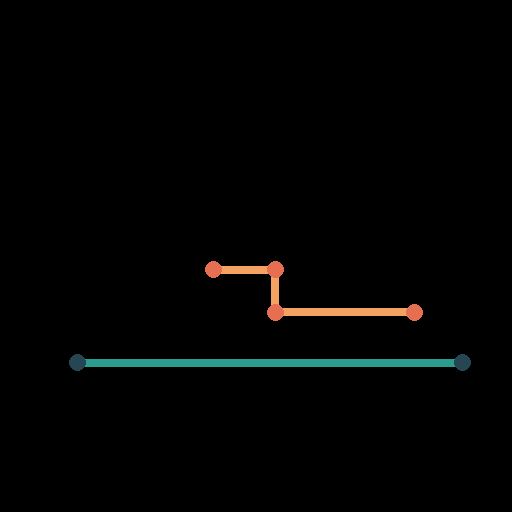

In [ ]:
path = 'images/126_IM-0176-2002.dcm'

features = model.extract_features_for_file(
    filename = path,
    feat_to_extract = 'CTR',
    draw = True,
)
print(features['score'])
features['drawing']


GDCMImageIO (0x557cbe1e61e0): Converting from MONOCHROME1 to MONOCHROME2 may impact the meaning of DICOM attributes related to pixel values.



The SCD for this image is: 22.990530139085948


/homes/constantin/.conda/envs/bidlord/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/homes/constantin/.conda/envs/bidlord/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


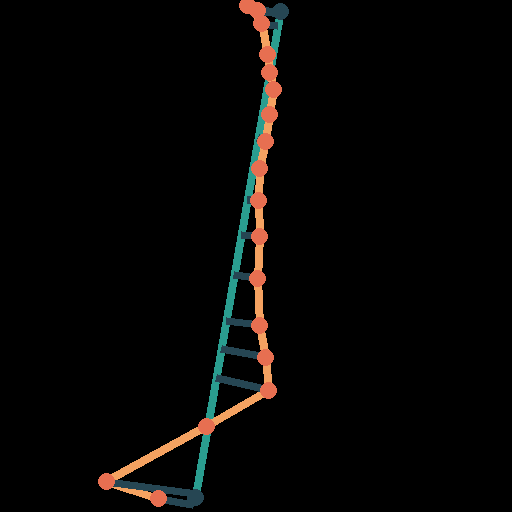

In [ ]:
path = 'images/126_IM-0176-2002.dcm'

features = model.extract_features_for_file(
    filename = path,
    feat_to_extract = 'SCD',
    draw = True,
)
print('The SCD'features['score'])
features['drawing']


# Extract Features for folder